# Vietnamese Emotion Classification - Data Augmentation with LLMs

## 🎯 Goals
1. Generate synthetic training data to balance classes
2. Increase dataset diversity and size
3. Improve model robustness

## 🔧 Features
- **Google Gemini** integration via LangChain
- **Batch processing** with async parallel requests
- **Few-shot prompting** for quality generation

## 📊 Dataset
- 7 emotions: Enjoyment, Disgust, Other, Sadness, Anger, Fear, Surprise
- Vietnamese social media text

## 1️⃣ Installation & Setup

In [72]:
%pip install -q langchain langchain-google-genai langchain-openai python-dotenv pandas tqdm nest_asyncio
print("✅ Packages installed successfully!")

I0000 00:00:1767416761.681448 29402459 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Packages installed successfully!


In [73]:
import os
import sys
import asyncio
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple
import time
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import nest_asyncio

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import ChatPromptTemplate
from dotenv import load_dotenv

nest_asyncio.apply()
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2️⃣ Configuration

In [74]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("📍 Running in Google Colab")
    from google.colab import userdata
    try:
        GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
        print("✅ Loaded Google Gemini API key from Colab Secrets")
    except:
        from getpass import getpass
        GOOGLE_API_KEY = getpass("Enter your Google Gemini API Key: ")
    os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY
else:
    print("📍 Running locally")
    load_dotenv()
    if not os.getenv('GOOGLE_API_KEY'):
        print("⚠️ Warning: No GOOGLE_API_KEY found in .env file")
    else:
        print("✅ Loaded Google Gemini API key from .env file")

print("✅ Configuration complete!")

📍 Running locally
✅ Loaded Google Gemini API key from .env file
✅ Configuration complete!


## 3️⃣ Load and Explore Data

In [75]:
# if IN_COLAB:
#     from google.colab import drive
#     drive.mount('/content/drive')
#     data_path = '/content/drive/MyDrive/thesis/data/train_nor_811.xlsx'
#     df_train = pd.read_excel(data_path)
# else:
#     data_path = './data/processed/train_org_processed.csv'
#     df_train = pd.read_csv(data_path)

# print(f"📊 Loaded {len(df_train)} training samples")
# print(f"📋 Columns: {df_train.columns.tolist()}")
# df_train.head()

In [ ]:
df_train = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_org_processed.csv')
df_train.head()
# Drop the Sentence_clean column if it exists
if 'Sentence_clean' in df_train.columns:
    df_train = df_train.drop('Sentence_clean', axis=1)
    print("✅ Dropped 'Sentence_clean' column")
else:
    print("ℹ️ 'Sentence_clean' column not found")

print(f"📋 Updated columns: {df_train.columns.tolist()}")


✅ Dropped 'Sentence_clean' column
📋 Updated columns: ['Sentence', 'Emotion', 'emotion_vn']


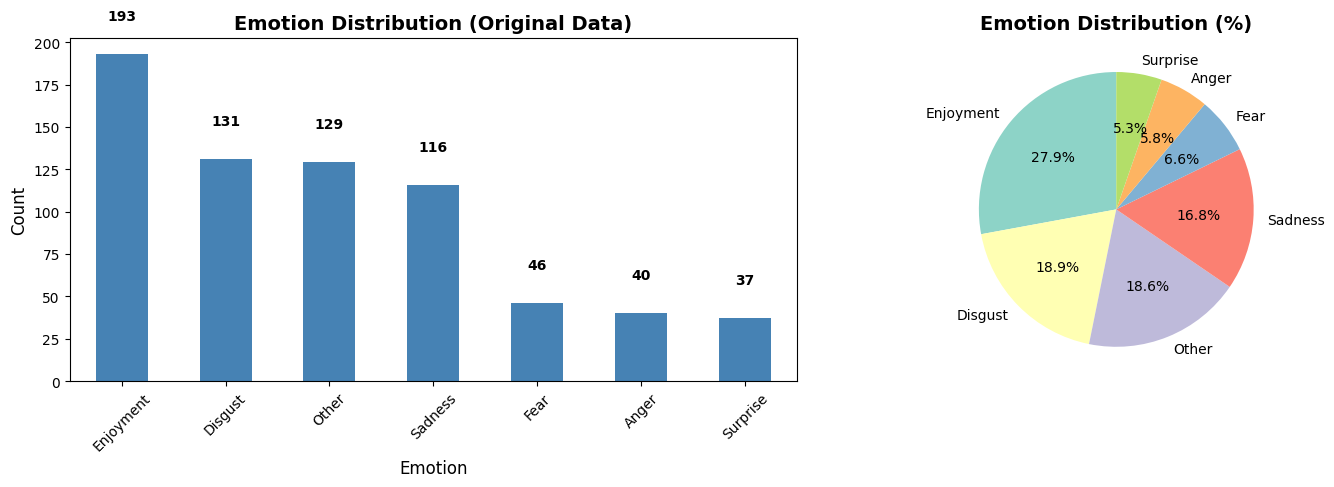

📊 Emotion Statistics:
Emotion
Enjoyment    193
Disgust      131
Other        129
Sadness      116
Fear          46
Anger         40
Surprise      37
Name: count, dtype: int64
⚖️ Imbalance ratio: 5.22x


In [77]:
emotion_counts = df_train['Emotion'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

emotion_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Emotion Distribution (Original Data)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Emotion', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(emotion_counts):
    ax1.text(i, v + 20, str(v), ha='center', fontweight='bold')

colors = plt.cm.Set3(range(len(emotion_counts)))
ax2.pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Emotion Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"📊 Emotion Statistics:")
print(emotion_counts)
print(f"⚖️ Imbalance ratio: {emotion_counts.max() / emotion_counts.min():.2f}x")

In [78]:
print("📝 Sample texts for each emotion:")
for emotion in df_train['Emotion'].unique():
    samples = df_train[df_train['Emotion'] == emotion]['Sentence'].head(2).tolist()
    print(f"{'='*60}")
    print(f"🏷️  {emotion}")
    print(f"{'='*60}")
    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")

📝 Sample texts for each emotion:
🏷️  Anger
1. mấy thằng ở ngoài bình luận gặp tao tao xé mỏ từng đứa . cha mẹ đéo dạy để xã hội dạy nhé . còn phèn lắm
2. cái lol mẹ đóng vào mồm thì có ở đấy mà đóng băng
🏷️  Sadness
1. cứu em nó với
2. đã check in thành công và mãi vẫn chưa gặp được người ấy là ai :((
🏷️  Other
1. đôi khi thích nói chuyện chỉ vì nói chuyện hợp và vì thích nói chuyện chứ thật ra chả phải yêu đương hay thích kiểu trai gái gì
2. thế ông bác sĩ đó bây giờ còn sống không 🙂
🏷️  Disgust
1. mất dạy từ nhỏ , đẹp mặt khi bố mẹ nó đang ngồi xem tivi , cứ tưởng hay
2. nhiều tiền để làm gì ..... đạo đức xã hội thế này thì đi học đâm chém chứ học chữ làm gì nữa 😢
🏷️  Enjoyment
1. chắc anh phải đáng yêu lắm luôn ý nhể 🤗🤗
2. đơn giản vậy thôi là đủ ❤️
🏷️  Surprise
1. cục cuối khủng bố vãi vậy :(
2. :)) thật là kì lạ
🏷️  Fear
1. cứu tao :(( tao sợ rắn
2. t cũng thế . đang ngồi chơi với con , vợ nó đắp mặt nạ lù lù bước vào . xém đái trog quần ??????


## 4️⃣ Batch Augmenter Class

Uses **LangChain's async batch processing** for efficient parallel API requests.

**Key Benefits:**
- Parallel processing reduces total execution time
- Rate limiting built-in to avoid API quota issues
- Few-shot prompting with random examples for diversity

In [79]:
class BatchEmotionAugmenterLangChain:
    """Batch data augmentation for Vietnamese emotion classification using LangChain's abatch()."""
    
    EMOTIONS = {
        'Enjoyment': 'vui vẻ', 'Disgust': 'khó chịu', 'Other': 'khác',
        'Sadness': 'buồn', 'Anger': 'giận dữ', 'Fear': 'sợ hãi', 'Surprise': 'ngạc nhiên'
    }
    
    def __init__(self, df: pd.DataFrame, model_name: str = "gemini-2.5-flash", 
                 temperature: float = 0.7, max_concurrency: int = 5, verbose: bool = True):
        self.df = df
        self.model_name = model_name
        self.temperature = temperature
        self.max_concurrency = max_concurrency
        self.verbose = verbose
        
        self.llm = ChatGoogleGenerativeAI(
            model=model_name, temperature=temperature,
            google_api_key=os.getenv("GOOGLE_API_KEY")
        )
        
        self.prompt = ChatPromptTemplate.from_messages([
            ("system", """You are an expert in Vietnamese Gen Z language, social media writing style.
Your task is to generate Vietnamese sentences while STRICTLY preserving:
- Core semantic meaning
- Emotional tone and intensity
- Speaker intent




All outputs must sound natural, realistic, and suitable for Vietnamese social media.
Do NOT introduce new facts, entities, time references, causes, or consequences.
Do NOT change sentiment polarity or emotional strength.
Use slang or emoji sparingly and only when they feel natural.
- DO NOT REPLACE: emotional particles (nhé, ạ, mà), negations (không, chẳng)
- ONLY augment: content words, not structure words
- Preserve: emotional intensifiers (rất, lắm, quá)
"""),
            ("human", """Generate exactly {num_variations} NEW Vietnamese sentences that preserve the SAME meaning and emotion as the example sentences below.

Emotion to preserve:
- English label: "{emotion}"
- Vietnamese description: "{emotion_vn}"

Example sentences:
1. "{example1}"
2. "{example2}"
3. "{example3}"
4. "{example4}"
5. "{example5}"
6. "{example6}"
7. "{example7}"
8. "{example8}"
9. "{example9}"
10. "{example10}"

SEMANTIC SIMILARITY CONSTRAINTS (MANDATORY):
1. Each generated sentence must be semantically equivalent to its source example:
   - No addition or removal of key actions, intentions, or outcomes
2. Preserve:
   - Subject (implicit or explicit)
   - Action/state
   - Target/object (if any)
   - Cause–effect relationship (if present)
3. Allowed changes:
   - Word choice (synonyms, paraphrasing)
   - Sentence structure (active/passive, reordering)
   - Discourse markers or softeners common in Gen Z Vietnamese
4. Forbidden changes:
   - Changing who is speaking or being referenced
   - Adding sarcasm if not present in the original
   - Adding intensity (e.g., “rất”, “quá trời”) unless present originally
   - Introducing new emotions or mixed emotions

STYLE & LENGTH CONSTRAINTS:
5. Length variation is required across outputs:
   - Short: 5–10 words
   - Medium: 10–20 words
   - Long: 20+ words
6. All sentences must be in Vietnamese.
7. Gen Z style must be natural, not exaggerated.
8. Emojis or slang:
   - Optional
   - Maximum 1 emoji per sentence
   - Must not change semantic meaning or emotion

OUTPUT FORMAT (STRICT):
Each line must follow this exact format:
[number]. [new Vietnamese sentence] (example [source_number])

Where:
- [number] is 1 to {num_variations}
- [source_number] is 1 to 10 (indicating which example sentence was paraphrased)

Example output format:
1. câu tiếng việt mới (example 1)
2. một câu khác (example 7)

Rules:
- One sentence per line
- No explanations, notes, or extra text
- Always include (example X) at the end where X is 1 to 10
""")
        ])
        
        self.chain = self.prompt | self.llm
        if self.verbose:
            print(f"✅ Initialized BatchEmotionAugmenterLangChain with {model_name}")
    
    def _get_few_shot_examples(self, emotion: str, num_examples: int = 10) -> List[str]:
        emotion_df = self.df[self.df['Emotion'] == emotion]
        replace = len(emotion_df) < num_examples
        return emotion_df['Sentence'].sample(n=num_examples, replace=replace).tolist()
    
    def _parse_generated_text(self, text: str, examples: List[str] = None) -> List[Dict[str, str]]:
        import re
        results = []
        for line in text.strip().split('\n'):
            line = line.strip()
            if not line:
                continue
            source_match = re.search(r'\((?:example\s*)?(\d+)\)\s*$', line, re.IGNORECASE)
            source_idx = int(source_match.group(1)) if source_match else None
            if source_match:
                line = line[:source_match.start()].strip()
            if line and line[0].isdigit() and '. ' in line:
                line = line.split('. ', 1)[-1]
            sentence = line.strip()
            if sentence:
                result = {'sentence': sentence, 'source_example_idx': source_idx}
                result['source_example'] = examples[source_idx - 1] if examples and source_idx and 1 <= source_idx <= len(examples) else None
                results.append(result)
        return results
    
    def prepare_batch_inputs(self, emotions_to_augment: List[str] = None,
                            num_variations_per_call: int = 5, num_calls_per_emotion: int = 10) -> List[Tuple[str, dict]]:
        emotions = emotions_to_augment or list(self.EMOTIONS.keys())
        inputs = []
        for emotion in emotions:
            for _ in range(num_calls_per_emotion):
                examples = self._get_few_shot_examples(emotion, 10)
                inputs.append((emotion, {
                    "emotion": emotion, "emotion_vn": self.EMOTIONS.get(emotion, emotion),
                    "example1": examples[0], "example2": examples[1], "example3": examples[2],
                    "example4": examples[3], "example5": examples[4], "example6": examples[5],
                    "example7": examples[6], "example8": examples[7], "example9": examples[8],
                    "example10": examples[9],
                    "num_variations": num_variations_per_call, "_examples": examples
                }))
        if self.verbose:
            print(f"📝 Prepared {len(inputs)} batch inputs (~{len(inputs) * num_variations_per_call} samples)")
        return inputs
    
    async def _run_batch_async(self, inputs: List[Tuple[str, dict]], delay: float = 1.0):
        results = []
        for i in range(0, len(inputs), self.max_concurrency):
            chunk = inputs[i:i + self.max_concurrency]
            if self.verbose:
                print(f"   Batch {i//self.max_concurrency + 1}/{(len(inputs) + self.max_concurrency - 1)//self.max_concurrency}...")
            try:
                responses = await self.chain.abatch([d for _, d in chunk], config={"max_concurrency": self.max_concurrency})
                for (emotion, input_dict), response in zip(chunk, responses):
                    results.append((emotion, response.content, input_dict.get('_examples', [])))
            except Exception as e:
                print(f"⚠️ Error: {e}")
                for emotion, _ in chunk:
                    results.append((emotion, "", []))
            if i + self.max_concurrency < len(inputs):
                await asyncio.sleep(delay)
        return results
    
    def run_batch_augmentation(self, emotions_to_augment: List[str] = None, num_variations_per_call: int = 5,
                               num_calls_per_emotion: int = 10, delay_between_batches: float = 1.0) -> pd.DataFrame:
        if self.verbose:
            print(f"🚀 Starting batch augmentation...")
        inputs = self.prepare_batch_inputs(emotions_to_augment, num_variations_per_call, num_calls_per_emotion)
        results = asyncio.run(self._run_batch_async(inputs, delay_between_batches))
        
        rows = []
        for emotion, text, examples in results:
            if text:
                for item in self._parse_generated_text(text, examples):
                    if item['sentence'].strip():
                        rows.append({
                            'Emotion': emotion, 'Sentence': item['sentence'].strip(),
                            'emotion_vn': self.EMOTIONS.get(emotion, ''), 'augmented': True,
                            'source': 'langchain_batch', 'source_example_idx': item.get('source_example_idx'),
                            'source_example': item.get('source_example')
                        })
        
        df = pd.DataFrame(rows)
        if self.verbose:
            print(f"✅ Generated {len(df)} samples")
            if len(df) > 0:
                print(df['Emotion'].value_counts())
        return df
    
    def combine_with_original(self, augmented_df: pd.DataFrame) -> pd.DataFrame:
        df_orig = self.df.copy()
        df_orig['augmented'] = False
        df_orig['source'] = 'original'
        combined = pd.concat([df_orig, augmented_df], ignore_index=True)
        if self.verbose:
            print(f"✅ Combined: {len(self.df)} original + {len(augmented_df)} augmented = {len(combined)} total")
        return combined

print("✅ BatchEmotionAugmenterLangChain class defined!")

✅ BatchEmotionAugmenterLangChain class defined!


In [80]:
# class BatchEmotionAugmenterLangChain:
#     """Batch data augmentation for Vietnamese emotion classification using LangChain's abatch()."""
    
#     EMOTIONS = {
#         'Enjoyment': 'vui vẻ', 'Disgust': 'khó chịu', 'Other': 'khác',
#         'Sadness': 'buồn', 'Anger': 'giận dữ', 'Fear': 'sợ hãi', 'Surprise': 'ngạc nhiên'
#     }
    
#     def __init__(self, df: pd.DataFrame, model_name: str = "gemini-2.5-flash", 
#                  temperature: float = 0.7, max_concurrency: int = 5, verbose: bool = True):
#         self.df = df
#         self.model_name = model_name
#         self.temperature = temperature
#         self.max_concurrency = max_concurrency
#         self.verbose = verbose
        
#         self.llm = ChatGoogleGenerativeAI(
#             model=model_name, temperature=temperature,
#             google_api_key=os.getenv("GOOGLE_API_KEY")
#         )
        
#         self.prompt = ChatPromptTemplate.from_messages([
#             ("system", """You are an expert in Vietnamese language, social media writing style.
# Your task is to generate Vietnamese sentences that is related to the given emotion while STRICTLY following the rules below:

# - All outputs must sound natural, realistic, and suitable for Vietnamese social media.
# - Only generate sentences that express the given emotion.
# - Use slang or emoji sparingly and only when they feel natural.
# """),
#             ("human", """Generate exactly {num_variations} NEW Vietnamese sentences that express the given emotion as the example sentences below.

# Emotion to generate:
# - English label: "{emotion}"
# - Vietnamese description: "{emotion_vn}"

# Example sentences:
# 1. "{example1}"
# 2. "{example2}"
# 3. "{example3}"
# 4. "{example4}"
# 5. "{example5}"
# 6. "{example6}"
# 7. "{example7}"
# 8. "{example8}"
# 9. "{example9}"
# 10. "{example10}"

# STYLE & LENGTH CONSTRAINTS:
# 5. Length variation is required across outputs:
#    - Short: 5–10 words
#    - Medium: 10–20 words
#    - Long: 20+ words
# 6. All sentences must be in Vietnamese.
# 7. Your sentence must not contain any other emotion than the given emotion.


# OUTPUT FORMAT (STRICT):
# Each line must follow this exact format:
# [number]. [new Vietnamese sentence] (example [source_number])

# Where:
# - [number] is 1 to {num_variations}
# - [source_number] is 1 to 10 (indicating which example sentence was paraphrased)

# Example output format:
# 1. câu tiếng việt mới (example 1)
# 2. một câu khác (example 7)

# Rules:
# - One sentence per line
# - No explanations, notes, or extra text
# - Always include (example X) at the end where X is 1 to 10
# """)
#         ])
        
#         self.chain = self.prompt | self.llm
#         if self.verbose:
#             print(f"✅ Initialized BatchEmotionAugmenterLangChain with {model_name}")
    
#     def _get_few_shot_examples(self, emotion: str, num_examples: int = 10) -> List[str]:
#         emotion_df = self.df[self.df['Emotion'] == emotion]
#         replace = len(emotion_df) < num_examples
#         return emotion_df['Sentence'].sample(n=num_examples, replace=replace).tolist()
    
#     def _parse_generated_text(self, text: str, examples: List[str] = None) -> List[Dict[str, str]]:
#         import re
#         results = []
#         for line in text.strip().split('\n'):
#             line = line.strip()
#             if not line:
#                 continue
#             source_match = re.search(r'\((?:example\s*)?(\d+)\)\s*$', line, re.IGNORECASE)
#             source_idx = int(source_match.group(1)) if source_match else None
#             if source_match:
#                 line = line[:source_match.start()].strip()
#             if line and line[0].isdigit() and '. ' in line:
#                 line = line.split('. ', 1)[-1]
#             sentence = line.strip()
#             if sentence:
#                 result = {'sentence': sentence, 'source_example_idx': source_idx}
#                 result['source_example'] = examples[source_idx - 1] if examples and source_idx and 1 <= source_idx <= len(examples) else None
#                 results.append(result)
#         return results
    
#     def prepare_batch_inputs(self, emotions_to_augment: List[str] = None,
#                             num_variations_per_call: int = 5, num_calls_per_emotion: int = 10) -> List[Tuple[str, dict]]:
#         emotions = emotions_to_augment or list(self.EMOTIONS.keys())
#         inputs = []
#         for emotion in emotions:
#             for _ in range(num_calls_per_emotion):
#                 examples = self._get_few_shot_examples(emotion, 10)
#                 inputs.append((emotion, {
#                     "emotion": emotion, "emotion_vn": self.EMOTIONS.get(emotion, emotion),
#                     "example1": examples[0], "example2": examples[1], "example3": examples[2],
#                     "example4": examples[3], "example5": examples[4], "example6": examples[5],
#                     "example7": examples[6], "example8": examples[7], "example9": examples[8],
#                     "example10": examples[9],
#                     "num_variations": num_variations_per_call, "_examples": examples
#                 }))
#         if self.verbose:
#             print(f"📝 Prepared {len(inputs)} batch inputs (~{len(inputs) * num_variations_per_call} samples)")
#         return inputs
    
#     async def _run_batch_async(self, inputs: List[Tuple[str, dict]], delay: float = 1.0):
#         results = []
#         for i in range(0, len(inputs), self.max_concurrency):
#             chunk = inputs[i:i + self.max_concurrency]
#             if self.verbose:
#                 print(f"   Batch {i//self.max_concurrency + 1}/{(len(inputs) + self.max_concurrency - 1)//self.max_concurrency}...")
#             try:
#                 responses = await self.chain.abatch([d for _, d in chunk], config={"max_concurrency": self.max_concurrency})
#                 for (emotion, input_dict), response in zip(chunk, responses):
#                     results.append((emotion, response.content, input_dict.get('_examples', [])))
#             except Exception as e:
#                 print(f"⚠️ Error: {e}")
#                 for emotion, _ in chunk:
#                     results.append((emotion, "", []))
#             if i + self.max_concurrency < len(inputs):
#                 await asyncio.sleep(delay)
#         return results
    
#     def run_batch_augmentation(self, emotions_to_augment: List[str] = None, num_variations_per_call: int = 5,
#                                num_calls_per_emotion: int = 10, delay_between_batches: float = 1.0) -> pd.DataFrame:
#         if self.verbose:
#             print(f"🚀 Starting batch augmentation...")
#         inputs = self.prepare_batch_inputs(emotions_to_augment, num_variations_per_call, num_calls_per_emotion)
#         results = asyncio.run(self._run_batch_async(inputs, delay_between_batches))
        
#         rows = []
#         for emotion, text, examples in results:
#             if text:
#                 for item in self._parse_generated_text(text, examples):
#                     if item['sentence'].strip():
#                         rows.append({
#                             'Emotion': emotion, 'Sentence': item['sentence'].strip(),
#                             'emotion_vn': self.EMOTIONS.get(emotion, ''), 'augmented': True,
#                             'source': 'langchain_batch', 'source_example_idx': item.get('source_example_idx'),
#                             'source_example': item.get('source_example')
#                         })
        
#         df = pd.DataFrame(rows)
#         if self.verbose:
#             print(f"✅ Generated {len(df)} samples")
#             if len(df) > 0:
#                 print(df['Emotion'].value_counts())
#         return df
    
#     def combine_with_original(self, augmented_df: pd.DataFrame) -> pd.DataFrame:
#         df_orig = self.df.copy()
#         df_orig['augmented'] = False
#         df_orig['source'] = 'original'
#         combined = pd.concat([df_orig, augmented_df], ignore_index=True)
#         if self.verbose:
#             print(f"✅ Combined: {len(self.df)} original + {len(augmented_df)} augmented = {len(combined)} total")
#         return combined

# print("✅ BatchEmotionAugmenterLangChain class defined!")

## 5️⃣ Balanced Augmentation Function

In [81]:
def run_balanced_augmentation(batch_augmenter, df_train: pd.DataFrame, target_per_emotion: int = 3000,
                               variations_per_call: int = 5, max_concurrency: int = 50,
                               delay_between_batches: float = 1, min_samples_to_augment: int = 50) -> pd.DataFrame:
    """Generate samples to balance dataset to target count per emotion."""
    current_counts = df_train['Emotion'].value_counts()
    all_augmented = []
    augmentation_plan = []
    
    print("=" * 60)
    print("📊 AUGMENTATION PLAN")
    print("=" * 60)
    
    for emotion in sorted(current_counts.index):
        count = current_counts[emotion]
        if count >= target_per_emotion:
            print(f"✅ {emotion}: {count} (skip - at target)")
            continue
        needed = target_per_emotion - count
        if needed < min_samples_to_augment:
            print(f"⏭️ {emotion}: {count} → {target_per_emotion} (skip - only {needed} needed)")
            continue
        num_calls = -(-needed // variations_per_call)
        augmentation_plan.append({'emotion': emotion, 'needed': needed, 'num_calls': num_calls})
        print(f"🔄 {emotion}: {count} → {target_per_emotion} (need {needed}, {num_calls} calls)")
    
    print("=" * 60)
    if not augmentation_plan:
        print("✅ No augmentation needed!")
        return pd.DataFrame()
    
    original_concurrency = batch_augmenter.max_concurrency
    batch_augmenter.max_concurrency = max_concurrency
    
    for item in augmentation_plan:
        emotion, needed, num_calls = item['emotion'], item['needed'], item['num_calls']
        print(f"🎯 Augmenting: {emotion} ({needed} samples)")
        try:
            aug_df = batch_augmenter.run_batch_augmentation(
                emotions_to_augment=[emotion], num_variations_per_call=variations_per_call,
                num_calls_per_emotion=num_calls, delay_between_batches=delay_between_batches
            )
            if len(aug_df) > 0:
                all_augmented.append(aug_df.head(needed))
                print(f"   ✅ Generated {min(len(aug_df), needed)} samples")
        except Exception as e:
            print(f"   ❌ Error: {e}")
    
    batch_augmenter.max_concurrency = original_concurrency
    
    if not all_augmented:
        return pd.DataFrame()
    
    final = pd.concat(all_augmented, ignore_index=True)
    print(f"🎉 COMPLETE! Total: {len(final)} samples")
    return final

print("✅ run_balanced_augmentation() defined!")

✅ run_balanced_augmentation() defined!


## 6️⃣ Run Augmentation

In [ ]:
# Initialize batch augmenter
batch_augmenter = BatchEmotionAugmenterLangChain(
    df=df_train,
    model_name="gemini-2.5-flash-lite",
    temperature=0.7,
    max_concurrency=50,
    verbose=True
)

# Run balanced augmentation
augmented_df = run_balanced_augmentation(
    batch_augmenter=batch_augmenter,
    df_train=df_train,
    target_per_emotion=1071,
    variations_per_call=10,
    max_concurrency=50,
    delay_between_batches=1,
    min_samples_to_augment=50
)

# Combine with original and save
combined_df = batch_augmenter.combine_with_original(augmented_df)
combined_df.to_csv('./data/processed/train_balanced_optimized.csv', index=False)
print(f"💾 Saved to ./data/processed/train_balanced_optimized.csv")

✅ Initialized BatchEmotionAugmenterLangChain with gemini-2.5-flash-lite
📊 AUGMENTATION PLAN
🔄 Anger: 40 → 129 (need 89, 5 calls)
✅ Disgust: 131 (skip - at target)
✅ Enjoyment: 193 (skip - at target)
🔄 Fear: 46 → 129 (need 83, 5 calls)
✅ Other: 129 (skip - at target)
⏭️ Sadness: 116 → 129 (skip - only 13 needed)
🔄 Surprise: 37 → 129 (need 92, 5 calls)
🎯 Augmenting: Anger (89 samples)
🚀 Starting batch augmentation...
📝 Prepared 5 batch inputs (~100 samples)
   Batch 1/1...


E0000 00:00:1767416764.449331 29402459 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1767416764.464533 29402459 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


✅ Generated 100 samples
Emotion
Anger    100
Name: count, dtype: int64
   ✅ Generated 89 samples
🎯 Augmenting: Fear (83 samples)
🚀 Starting batch augmentation...
📝 Prepared 5 batch inputs (~100 samples)
   Batch 1/1...
✅ Generated 100 samples
Emotion
Fear    100
Name: count, dtype: int64
   ✅ Generated 83 samples
🎯 Augmenting: Surprise (92 samples)
🚀 Starting batch augmentation...
📝 Prepared 5 batch inputs (~100 samples)
   Batch 1/1...
✅ Generated 100 samples
Emotion
Surprise    100
Name: count, dtype: int64
   ✅ Generated 92 samples
🎉 COMPLETE! Total: 264 samples
✅ Combined: 692 original + 264 augmented = 956 total
💾 Saved to ./data/processed/train_balanced_optimized.csv


## 7️⃣ Post-Processing

In [83]:
# Load and verify
train_balanced = pd.read_csv('./data/processed/train_balanced_optimized.csv')

# Fix emotion_vn values
train_balanced['emotion_vn'] = train_balanced['emotion_vn'].replace('buồn bã', 'buồn')

print("📊 Distribution:")
print(train_balanced['emotion_vn'].value_counts())
train_balanced.head()

📊 Distribution:
emotion_vn
vui vẻ        193
khó chịu      131
giận dữ       129
khác          129
ngạc nhiên    129
sợ hãi        129
buồn          116
Name: count, dtype: int64


,Sentence,Emotion,emotion_vn,augmented,source,source_example_idx,source_example
0,mấy thằng ở ngoài bình luận gặp tao tao xé mỏ ...,Anger,giận dữ,False,original,NaN,NaN
1,cứu em nó với,Sadness,buồn,False,original,NaN,NaN
2,đôi khi thích nói chuyện chỉ vì nói chuyện hợp...,Other,khác,False,original,NaN,NaN
3,"mất dạy từ nhỏ , đẹp mặt khi bố mẹ nó đang ngồ...",Disgust,khó chịu,False,original,NaN,NaN
4,chắc anh phải đáng yêu lắm luôn ý nhể 🤗🤗,Enjoyment,vui vẻ,False,original,NaN,NaN


In [ ]:
# Export clean dataset
train_clean = train_balanced.drop(['augmented', 'source'], axis=1, errors='ignore')

clean_path = './data/processed/train_1071_new_clean.csv'
train_clean.to_csv(clean_path, index=False, encoding='utf8')

print(f"✅ Saved: {clean_path}")
print(f"   Samples: {len(train_clean)}")
print(f"   Columns: {list(train_clean.columns)}")

✅ Saved: ./data/processed/test_org_clean.csv
   Samples: 956
   Columns: ['Sentence', 'Emotion', 'emotion_vn', 'source_example_idx', 'source_example']


In [85]:
# Verify final dataset
print("🔍 Final dataset check:")
print(f"   Unique emotions: {train_clean['emotion_vn'].nunique()}")
print(f"   Missing values: {train_clean['emotion_vn'].isnull().sum()}")
print(f"📊 Distribution:")
print(train_clean['emotion_vn'].value_counts())

🔍 Final dataset check:
   Unique emotions: 7
   Missing values: 0
📊 Distribution:
emotion_vn
vui vẻ        193
khó chịu      131
giận dữ       129
khác          129
ngạc nhiên    129
sợ hãi        129
buồn          116
Name: count, dtype: int64


## 8️⃣ Cleanup

In [86]:
import gc
gc.collect()
print("✅ Memory cleared.")

✅ Memory cleared.
